# Synthetic Data Generation 可視化流程

這份 Notebook 對照 `synthetic_data_generation.md`，逐步展示「假資料生成」與「表格渲染檢測」每一步實際會產生什麼內容，方便你調參。


## 0) 初始化與參數

> 你可以先改 `SEED` / `TEMPLATE_IMAGE` 來觀察不同結果。


In [49]:
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

from score_reader.dataset.generator.ground_truth_generator import GroundTruthGenerator
from score_reader.dataset.generator.sheet_renderer import SheetRenderer
from score_reader.dataset.models import SyntheticSheet

SEED = 42
TEMPLATE_IMAGE = Path("../sample.png")
assert TEMPLATE_IMAGE.exists(), f"找不到模板圖片: {TEMPLATE_IMAGE}"

rng = random.Random(SEED)
gt = GroundTruthGenerator(rng=rng)
renderer = SheetRenderer()

## 1) 產生 ground truth（第一大項）

這一步先不畫圖，直接印出「預期要填進去」的假資料內容。


In [50]:
targets = [gt.generate_target(i) for i in range(4)]
sheet = SyntheticSheet(image_id="demo_notebook", seed=SEED, targets=targets)
print(f"image_id={sheet.image_id}, seed={sheet.seed}")
print(f"targets={len(sheet.targets)}")

image_id=demo_notebook, seed=42
targets=4


In [51]:
# 展示第 1 位選手（target_1）每一個 end 的細節：
t0 = sheet.targets[0]
print("target_index:", t0.target_index)
print("target_no:", t0.target_no)

print("\n[每局內容]")
for i, end in enumerate(t0.rounds, start=1):
    arrows = [a.value for a in end.arrows]
    print(f"end {i}: arrows={arrows}, subtotal={end.subtotal}, cumulative={end.cumulative}")
print("\n[總結]")
print("x_count=", t0.x_count)
print("x_plus_ten_count=", t0.x_plus_ten_count)
print("total=", t0.total)

target_index: 0
target_no: 1A

[每局內容]
end 1: arrows=['1', '10', 'X', 'M', '7', '8'], subtotal=36, cumulative=36
end 2: arrows=['8', '9', 'M', '10', '1', 'M'], subtotal=28, cumulative=64
end 3: arrows=['3', '10', '2', '5', 'X', 'X'], subtotal=40, cumulative=104
end 4: arrows=['10', '8', '8', '3', '2', 'X'], subtotal=41, cumulative=145
end 5: arrows=['3', '8', 'M', '1', 'M', '3'], subtotal=15, cumulative=160
end 6: arrows=['5', '8', '4', '2', '7', 'X'], subtotal=36, cumulative=196

[總結]
x_count= 5
x_plus_ten_count= 9
total= 196


## 2) Rendering into template（第二大項）

以下 cells 專注在你指定的重點：
- 檢測到的行（lines）用**淺綠色**標註。
- 檢測到的選手區域用**紅色框**。
- 每一個小框（cell）用**淺藍色**標註。


In [52]:
img = Image.open(TEMPLATE_IMAGE).convert("RGB")
gray = img.convert("L")
arr = np.array(gray)
h, w = arr.shape
print(f"template size: {w} x {h}")


template size: 1100 x 769


In [55]:
# 2.1 Detect table lines
# 直接對照 SheetRenderer._detect_cells 內部邏輯
dark_cols = [x for x in range(w) if (arr[:, x] < 160).sum() > h * 0.20]
dark_rows = [y for y in range(h) if (arr[y, :] < 160).sum() > w * 0.20]

v_lines = renderer._merge_lines(dark_cols)
h_lines = renderer._merge_lines(dark_rows)

print("raw dark cols:", len(dark_cols), "=> merged vertical lines:", len(v_lines))
print("raw dark rows:", len(dark_rows), "=> merged horizontal lines:", len(h_lines))
print("first few v_lines:", v_lines[:50])
print("first few h_lines:", h_lines[:50])


raw dark cols: 45 => merged vertical lines: 32
raw dark rows: 38 => merged horizontal lines: 24
first few v_lines: [44, 56, 98, 139, 181, 217, 253, 289, 301, 313, 355, 396, 438, 474, 510, 546, 558, 570, 612, 654, 695, 731, 767, 803, 818, 830, 872, 913, 955, 991, 1027, 1063]
first few h_lines: [42, 99, 127, 150, 172, 192, 208, 234, 260, 285, 311, 336, 362, 388, 413, 439, 464, 490, 515, 541, 566, 618, 634, 679]


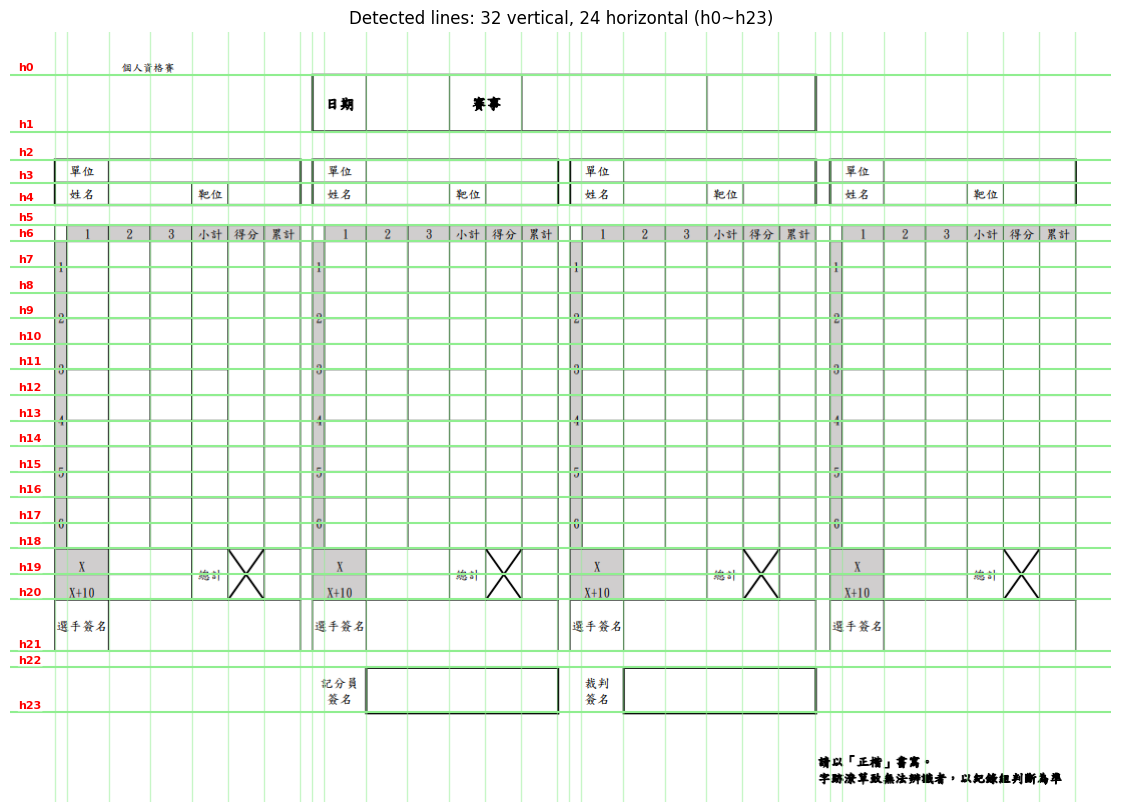

h_lines index → y position → gap to next:
  h 0  y= 42  gap=57
  h 1  y= 99  gap=28
  h 2  y=127  gap=23
  h 3  y=150  gap=22
  h 4  y=172  gap=20
  h 5  y=192  gap=16
  h 6  y=208  gap=26
  h 7  y=234  gap=26
  h 8  y=260  gap=25
  h 9  y=285  gap=26
  h10  y=311  gap=25
  h11  y=336  gap=26
  h12  y=362  gap=26
  h13  y=388  gap=25
  h14  y=413  gap=26
  h15  y=439  gap=25
  h16  y=464  gap=26
  h17  y=490  gap=25
  h18  y=515  gap=26
  h19  y=541  gap=25
  h20  y=566  gap=52
  h21  y=618  gap=16
  h22  y=634  gap=45
  h23  y=679


In [56]:
# 視覺化：檢測到的行（淺綠），橫線標 index
fig, ax = plt.subplots(figsize=(18, 10))
ax.imshow(img)
for x in v_lines:
    ax.axvline(x=x, color="#90EE90", linewidth=1.0, alpha=0.5)
for idx, y in enumerate(h_lines):
    ax.axhline(y=y, color="#90EE90", linewidth=1.5)
    ax.text(8, y - 2, f"h{idx}", color="red", fontsize=8, weight="bold",
            va="bottom", bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))
ax.set_title(f"Detected lines: {len(v_lines)} vertical, {len(h_lines)} horizontal (h0~h{len(h_lines)-1})")
ax.axis("off")
plt.show()

# 也印出完整 h_lines 對照表
print("h_lines index → y position → gap to next:")
for idx, y in enumerate(h_lines):
    gap = f"  gap={h_lines[idx+1] - y}" if idx < len(h_lines) - 1 else ""
    print(f"  h{idx:2d}  y={y:3d}{gap}")

In [57]:
# 2.1b 用 OpenCV findContours + approxPolyDP 偵測矩形（放寬條件）
import cv2

total_area = w * h
target_area = total_area / 8
tolerance = 0.5   # ±50%（放寬）
area_lo = target_area * (1 - tolerance)
area_hi = target_area * (1 + tolerance)

# 二值化
_, binary = cv2.threshold(arr, 110, 255, cv2.THRESH_BINARY_INV)

# 找輪廓
contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"找到 {len(contours)} 個輪廓\n")

# 第一階段：只用面積篩選，看頂點數分佈
area_matched = []
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if not (area_lo <= area <= area_hi):
        continue
    peri = cv2.arcLength(cnt, True)
    # 試多種 epsilon
    for eps_pct in [0.01, 0.02, 0.03, 0.05, 0.08]:
        approx = cv2.approxPolyDP(cnt, eps_pct * peri, True)
        n_verts = len(approx)
        if n_verts <= 6:  # 放寬到 4~6 頂點
            x, y, rw, rh = cv2.boundingRect(approx)
            area_matched.append({
                "index": i,
                "approx": approx,
                "bbox": (x, y, x + rw, y + rh),
                "area": area,
                "vertices": n_verts,
                "epsilon_pct": eps_pct,
                "aspect": rw / rh if rh > 0 else 0,
            })
            break  # 用最小的 epsilon 就能 ≤6 頂點，就用這個

print(f"面積 ≈ 1/8 且 ≤6 頂點: {len(area_matched)} 個\n")

# 也列出面積符合但頂點數 > 6 的，方便觀察
rejected = []
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if not (area_lo <= area <= area_hi):
        continue
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    x, y, rw, rh = cv2.boundingRect(approx)
    rejected.append({
        "index": i,
        "bbox": (x, y, x + rw, y + rh),
        "area": area,
        "vertices": len(approx),
    })

print(f"面積符合的所有輪廓（不限頂點數）: {len(rejected)} 個")
print("頂點數分佈:")
from collections import Counter
vert_counts = Counter(r["vertices"] for r in rejected)
for v, cnt in sorted(vert_counts.items()):
    print(f"  {v} 頂點: {cnt} 個")

print("\n--- 面積符合的所有輪廓明細 ---")
for rank, r in enumerate(rejected, 1):
    x1, y1, x2, y2 = r["bbox"]
    print(f"  #{rank:2d}  contour={r['index']:3d}  verts={r['vertices']:2d}  "
          f"bbox=({x1:4d},{y1:3d})-({x2:4d},{y2:3d})  "
          f"w={x2-x1:3d} h={y2-y1:3d}  area={r['area']:.0f}")

# 最終候選 = area_matched
candidates = area_matched

找到 826 個輪廓

面積 ≈ 1/8 且 ≤6 頂點: 4 個

面積符合的所有輪廓（不限頂點數）: 4 個
頂點數分佈:
  4 頂點: 1 個
  7 頂點: 2 個
  17 頂點: 1 個

--- 面積符合的所有輪廓明細 ---
  # 1  contour=133  verts= 4  bbox=( 818,193)-(1064,619)  w=246 h=426  area=103934
  # 2  contour=279  verts= 7  bbox=( 559,193)-( 805,619)  w=246 h=426  area=101234
  # 3  contour=407  verts=17  bbox=( 302,193)-( 548,619)  w=246 h=426  area=66712
  # 4  contour=522  verts= 7  bbox=(  44,193)-( 291,619)  w=247 h=426  area=81322


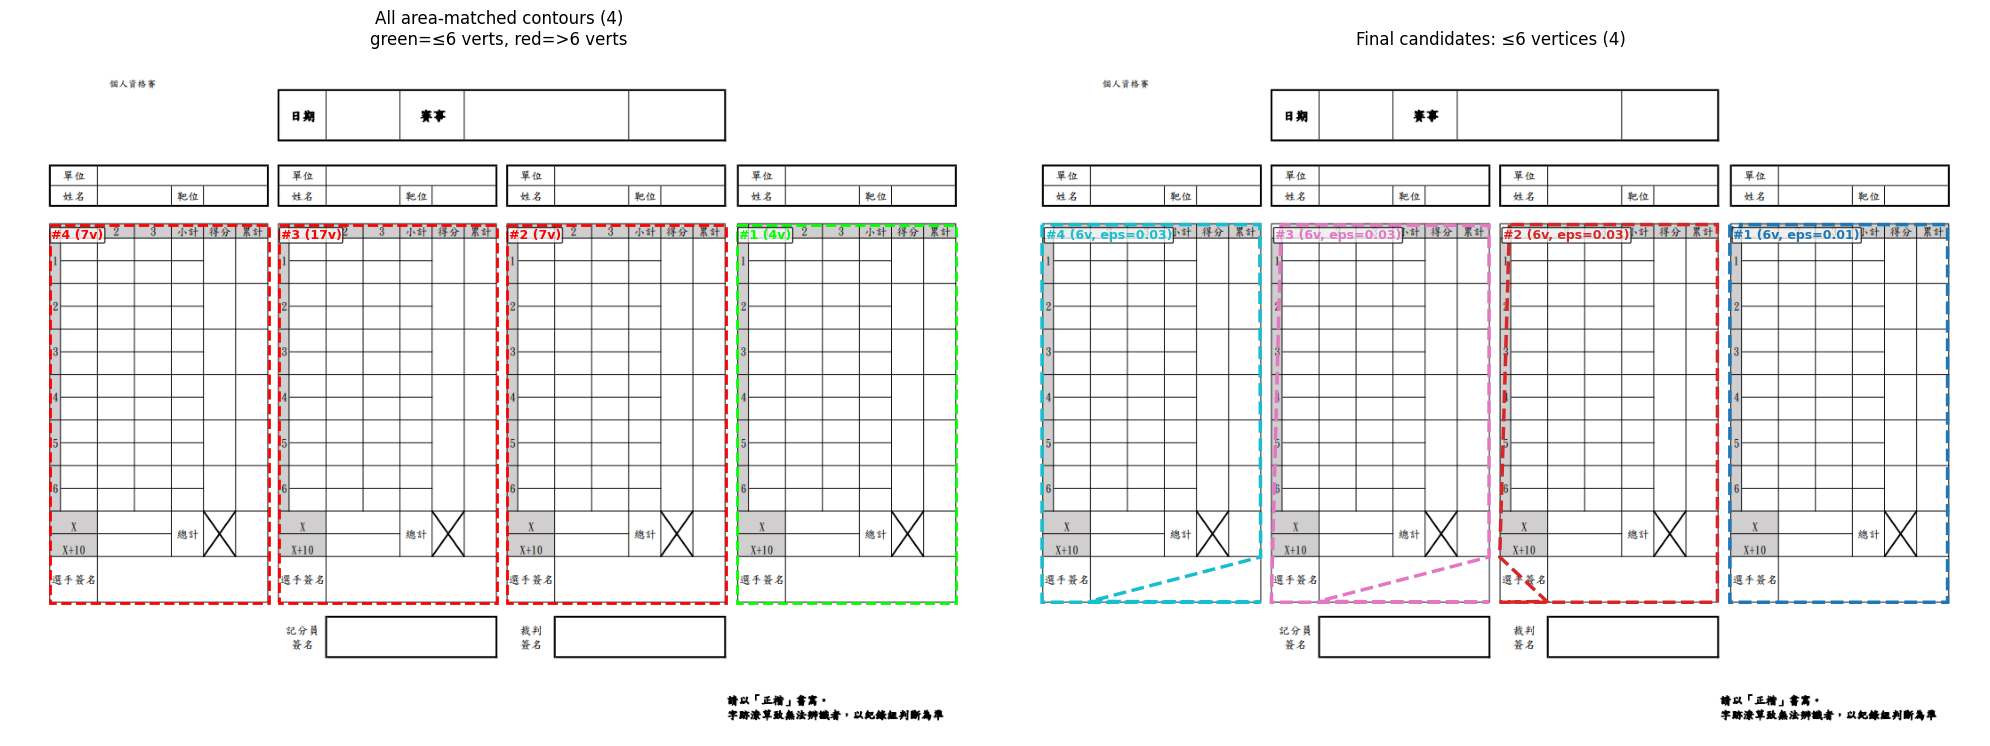

In [58]:
# 2.1c 視覺化：面積符合的所有輪廓（不限頂點數）
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 左圖：所有面積符合的輪廓
ax = axes[0]
ax.imshow(img)
for rank, r in enumerate(rejected):
    x1, y1, x2, y2 = r["bbox"]
    color = "red" if r["vertices"] > 6 else "lime"
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                            fill=False, edgecolor=color, linewidth=2.0, linestyle="--"))
    ax.text(x1 + 2, y1 + 16, f"#{rank+1} ({r['vertices']}v)",
            color=color, fontsize=9, weight="bold",
            bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))
ax.set_title(f"All area-matched contours ({len(rejected)})\ngreen=≤6 verts, red=>6 verts")
ax.axis("off")

# 右圖：最終候選（≤6 頂點）
ax = axes[1]
ax.imshow(img)
colors = plt.cm.tab10(np.linspace(0, 1, max(len(candidates), 1)))
for rank, c in enumerate(candidates):
    pts = c["approx"].reshape(-1, 2)
    polygon = plt.Polygon(pts, fill=False, edgecolor=colors[rank],
                          linewidth=2.5, linestyle="--")
    ax.add_patch(polygon)
    x1, y1, _, _ = c["bbox"]
    ax.text(x1 + 4, y1 + 16,
            f"#{rank+1} ({c['vertices']}v, eps={c['epsilon_pct']})",
            color=colors[rank], fontsize=9, weight="bold",
            bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7))
ax.set_title(f"Final candidates: ≤6 vertices ({len(candidates)})")
ax.axis("off")

plt.tight_layout()
plt.show()

In [59]:
# 2.2 Detect 4 athlete scoring regions（使用新的 OpenCV 方法）
regions = renderer._detect_target_regions(arr)
print("detected regions:", len(regions))
for i, (l, t, r, b) in enumerate(regions, start=1):
    print(f"region {i}: left={l}, top={t}, right={r}, bottom={b}, w={r-l}, h={b-t}")

detected regions: 4
region 1: left=44, top=193, right=291, bottom=619, w=247, h=426
region 2: left=301, top=193, right=548, bottom=619, w=247, h=426
region 3: left=559, top=193, right=805, bottom=619, w=246, h=426
region 4: left=818, top=193, right=1064, bottom=619, w=246, h=426


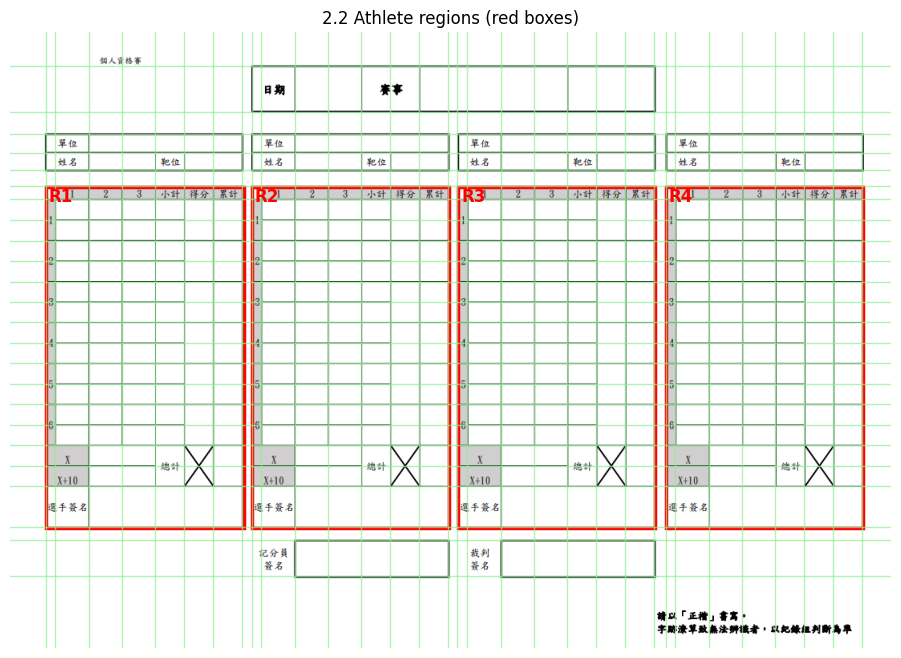

In [60]:
# 視覺化：淺綠 lines + 紅色選手區域框
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)
for x in v_lines:
    ax.axvline(x=x, color="#90EE90", linewidth=1.0, alpha=0.7)
for y in h_lines:
    ax.axhline(y=y, color="#90EE90", linewidth=1.0, alpha=0.7)

for i, (l, t, r, b) in enumerate(regions, start=1):
    ax.add_patch(Rectangle((l, t), r-l, b-t, fill=False, edgecolor="red", linewidth=2.5))
    ax.text(l+4, t+18, f"R{i}", color="red", fontsize=12, weight="bold")

ax.set_title("2.2 Athlete regions (red boxes)")
ax.axis("off")
plt.show()


In [61]:
# 2.3 Build inner cells（按 region 分組）
cells = []
for (left, top, right, bottom) in regions:
    local_v = [x for x in v_lines if left <= x <= right]
    local_h = [y for y in h_lines if top <= y <= bottom]

    region_cells = []
    for r1, r2 in zip(local_h, local_h[1:]):
        row_h = r2 - r1
        if row_h < 22 or row_h > 110:
            continue
        for c1, c2 in zip(local_v, local_v[1:]):
            col_w = c2 - c1
            if col_w < 24 or col_w > 170:
                continue
            region_cells.append((c1 + 3, r1 + 3, c2 - 3, r2 - 3))

    region_cells.sort(key=lambda c: (c[1], c[0]))
    cells.extend(region_cells)

print("detected inner cells:", len(cells))
print("first 10 cells:", cells[:10])

detected inner cells: 360
first 10 cells: [(59, 211, 95, 231), (101, 211, 136, 231), (142, 211, 178, 231), (184, 211, 214, 231), (220, 211, 250, 231), (256, 211, 286, 231), (59, 237, 95, 257), (101, 237, 136, 257), (142, 237, 178, 257), (184, 237, 214, 257)]


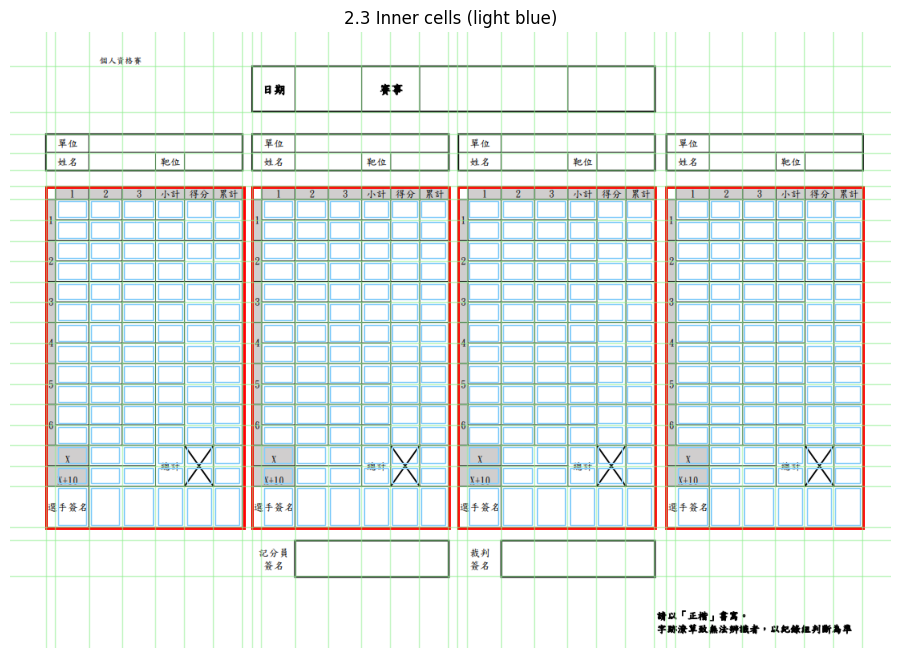

In [62]:
# 視覺化：淺綠 lines + 紅框 regions + 淺藍小框 cells
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)

for x in v_lines:
    ax.axvline(x=x, color="#90EE90", linewidth=1.0, alpha=0.5)
for y in h_lines:
    ax.axhline(y=y, color="#90EE90", linewidth=1.0, alpha=0.5)

for (l, t, r, b) in regions:
    ax.add_patch(Rectangle((l, t), r-l, b-t, fill=False, edgecolor="red", linewidth=2.0))

for (l, t, r, b) in cells:
    ax.add_patch(Rectangle((l, t), r-l, b-t, fill=False, edgecolor="#87CEFA", linewidth=1.0))  # light blue

ax.set_title("2.3 Inner cells (light blue)")
ax.axis("off")
plt.show()


In [63]:
# 2.3 + flatten values：確認「要填進 cell 的值順序」
flat_values = renderer._flatten_values(sheet.targets)
print("flatten values:", len(flat_values))
print("first 40 values:")
print(flat_values[:40])

print("\n實際可填數量:", min(len(cells), len(flat_values)))
if len(cells) < len(flat_values):
    print("⚠️ cells 不足，後面的值不會被畫上去。")
elif len(cells) > len(flat_values):
    print("ℹ️ cells 較多，尾端小框會保持空白。")


flatten values: 204
first 40 values:
['1', '10', 'X', 'M', '7', '8', '36', '36', '8', '9', 'M', '10', '1', 'M', '28', '64', '3', '10', '2', '5', 'X', 'X', '40', '104', '10', '8', '8', '3', '2', 'X', '41', '145', '3', '8', 'M', '1', 'M', '3', '15', '160']

實際可填數量: 204
ℹ️ cells 較多，尾端小框會保持空白。
